==============================
# Support Vector Machine
==============================

"""Why do we choose Support Vector Machine (SVM) for Classification?

We choose SVM because it tries to find the best possible decision boundary that separates different classes while maximizing the distance (margin) between them.

Unlike many classifiers that only focus on making correct predictions on the training data, SVM aims to create a boundary that is more likely to generalize well to unseen data."""

In [16]:

# Math Library
import numpy as np

# Data CLeaning Library
import pandas as pd

# Data visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection 
from sklearn.svm import SVC

# Spliting
from sklearn.model_selection import train_test_split

# Load dataset
from sklearn.datasets import load_breast_cancer

# Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Evaluation Metrics
from sklearn.metrics import(
    confusion_matrix,
    classification_report, 
    accuracy_score,
    
)

Why I choose the Breast-Cancer-Dataset for Support Vector Classification?

I chose the Breast Cancer Wisconsin dataset because it is a well-known binary classification benchmark with 30 numerical features and 569 samples. It requires feature scaling, which is essential for SVM, and its size allows fast experimentation with different kernels and hyperparameters such as C and gamma. Since the classes are reasonably separable and the dataset is widely used in academia and industry, it is an excellent dataset for understanding the core concepts and performance of Support Vector Machines.

==================================================
# Load Dataset 
==================================================

In [17]:
data = load_breast_cancer()


In [18]:
type(data)

sklearn.utils._bunch.Bunch

In [19]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

======================================
# Create DataFrame
======================================

In [20]:
df = pd.DataFrame(
    data.data, 
    columns=data.feature_names
)

In [21]:
df['target'] = data.target

=======================================================
# Data Analysis
=======================================================

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [7]:
df.shape

(569, 33)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop('Unnamed: 32', axis=1, inplace=True)

#  Unnamed: 32 is a extra features so it drop it.

In [11]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

=================================
# Target Distribution
=================================

In [28]:
df['target'].value_counts(normalize=True)*100

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64

The target variable shows a moderate class imbalance (approximately 63% benign and 37% malignant). Although the dataset is not perfectly balanced, the minority class has sufficient samples for model training. Therefore, oversampling techniques such as SMOTE are not required initially. Model performance will be evaluated using precision, recall, F1-score, and the confusion matrix to determine whether additional imbalance-handling techniques are necessary.

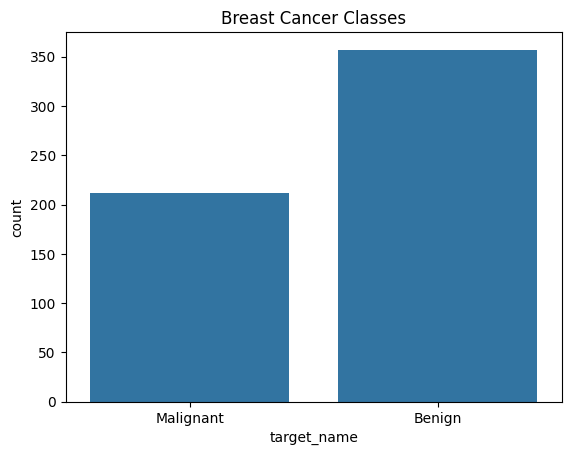

In [27]:
df["target_name"] = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

sns.countplot(data=df, x="target_name")

plt.title("Breast Cancer Classes")
plt.show()

====================================================
# Feature Analysis & Visualization
====================================================

=====================================
# Distribution of Features
=====================================

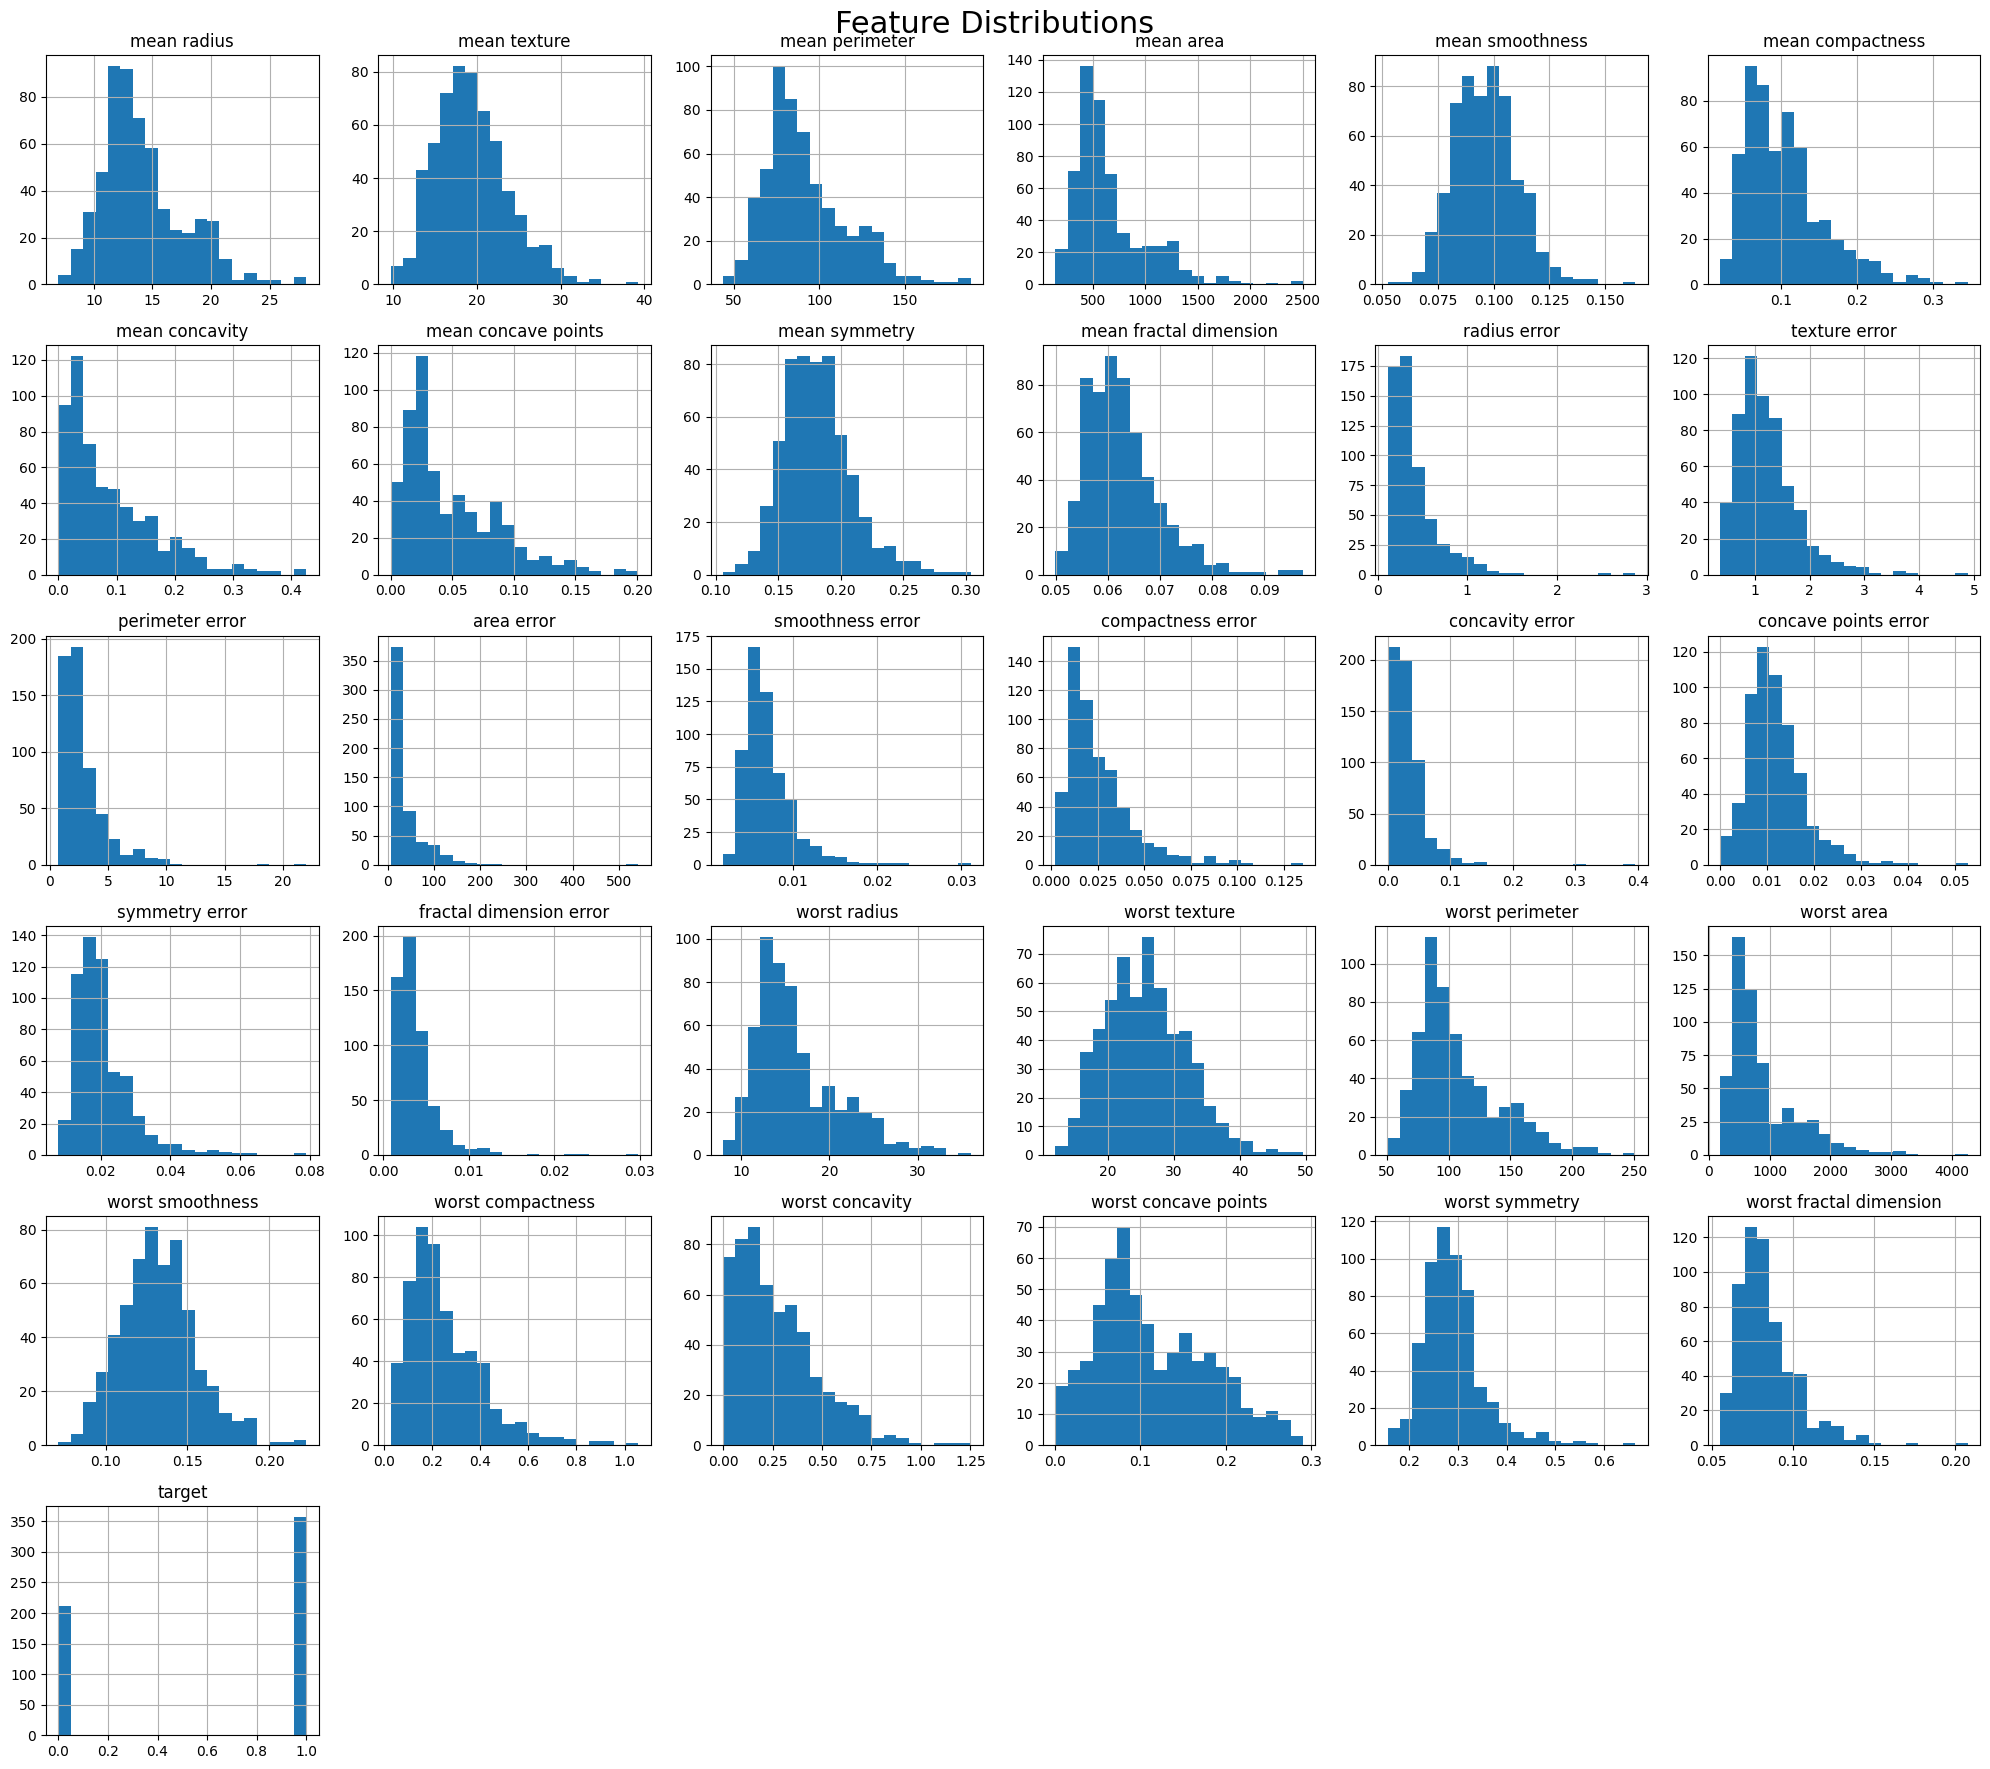

In [30]:
# Plot Histograms
df.hist(figsize=(20,18), bins=20)
plt.suptitle('Feature Distributions', fontsize=22)
plt.tight_layout()
plt.show()

The data is mostly skewed, and the worst area , mean area and area error contains the outliers. 

==============================================
# Boxplots (Outlier Detection)
==============================================

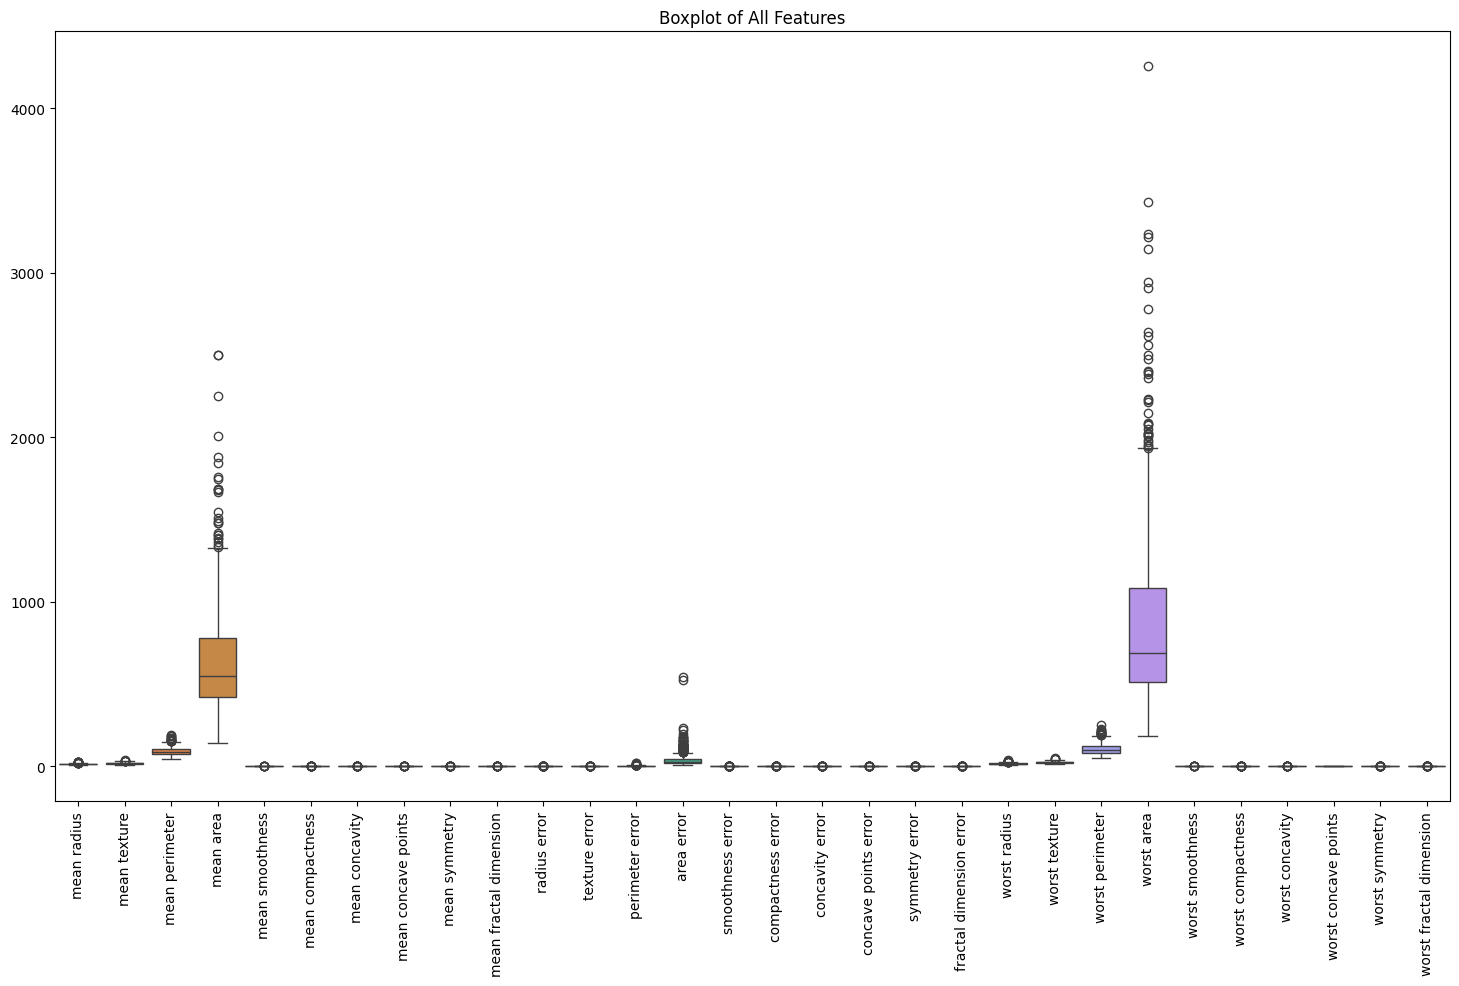

In [31]:
plt.figure(figsize=(18,10))

sns.boxplot(data=df.drop(columns=["target", "target_name"]))

plt.xticks(rotation=90)
plt.title("Boxplot of All Features")
plt.show()

========================================
# Correlation Matrix
========================================

In [36]:
corr = df.drop(columns=["target", "target_name"]).corr()

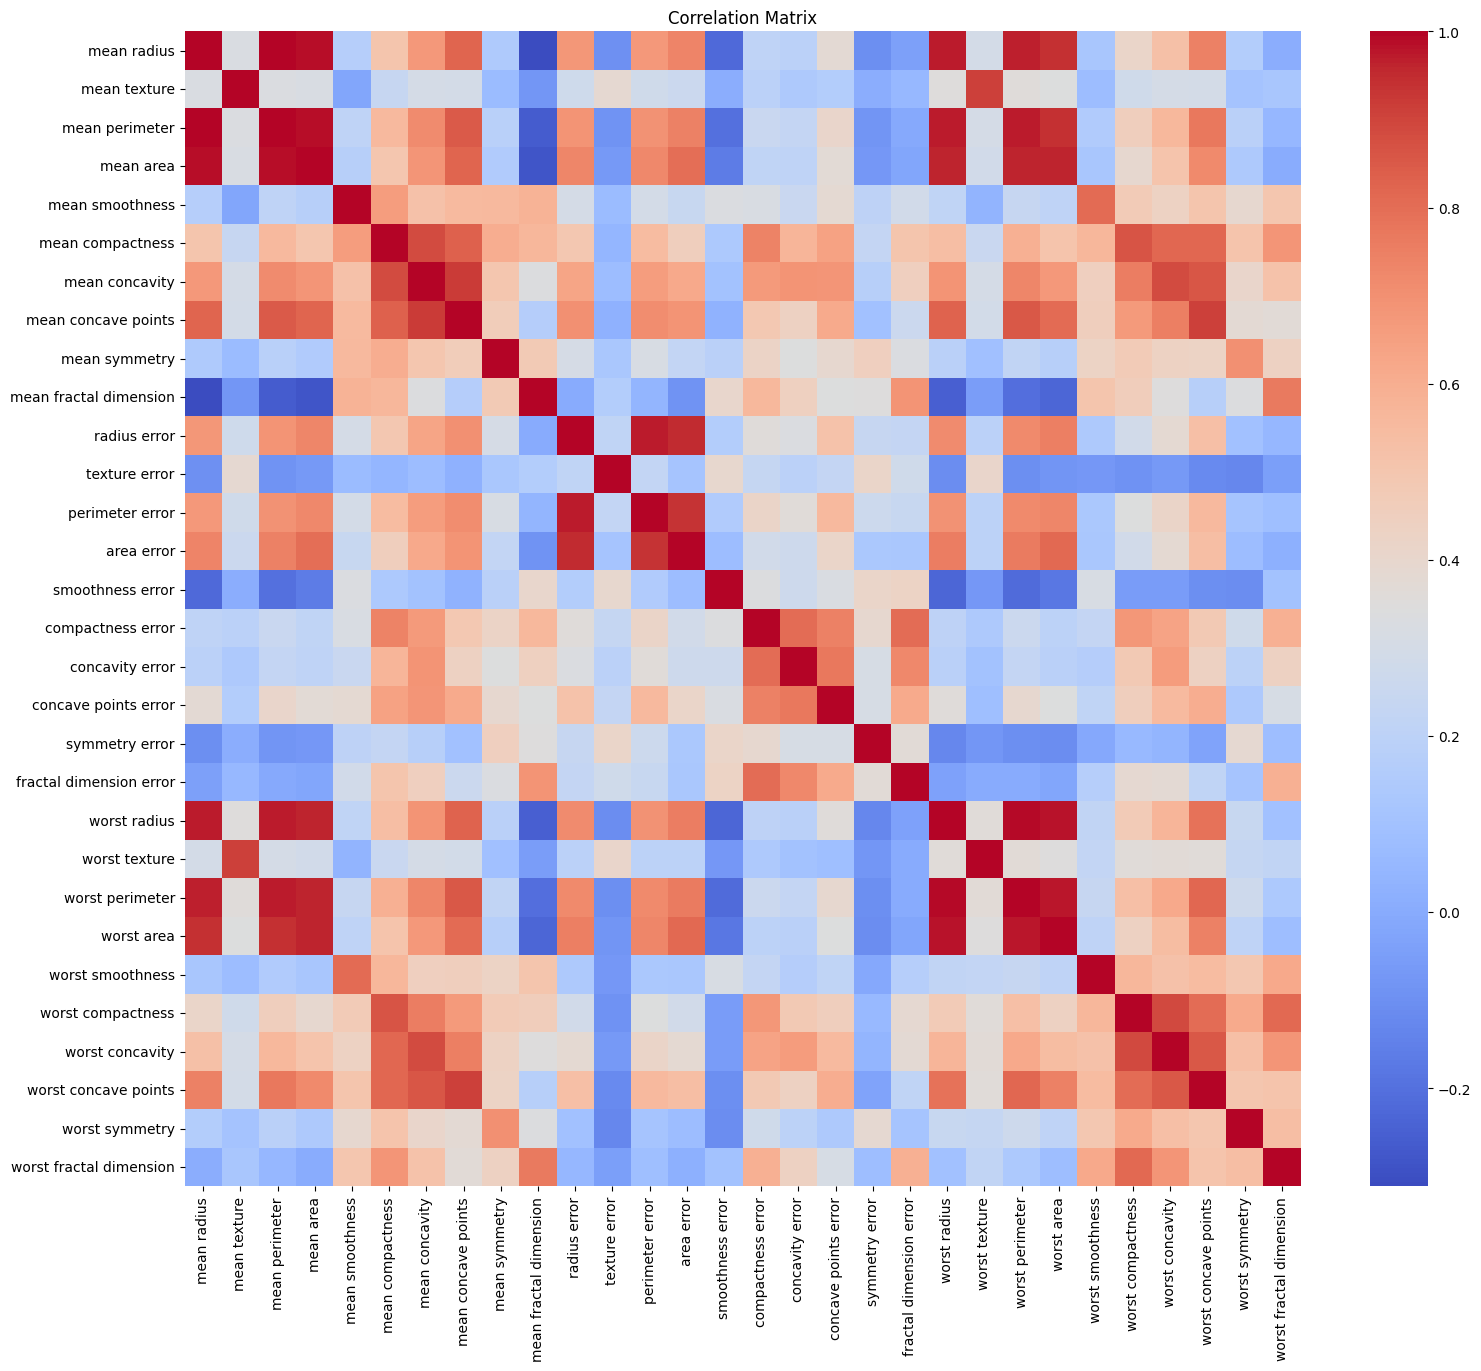

In [38]:
# Heatmap
plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

============================================
# Relationship with Target
============================================

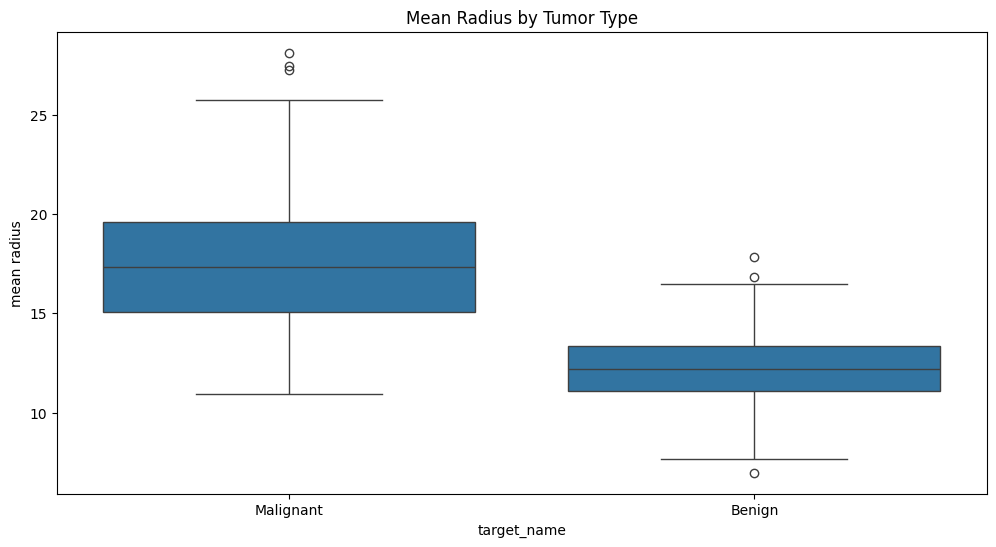

In [39]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="target_name",
    y="mean radius"
)

plt.title("Mean Radius by Tumor Type")
plt.show()

=====================================================
# Pairplot (Selected Features)
=====================================================

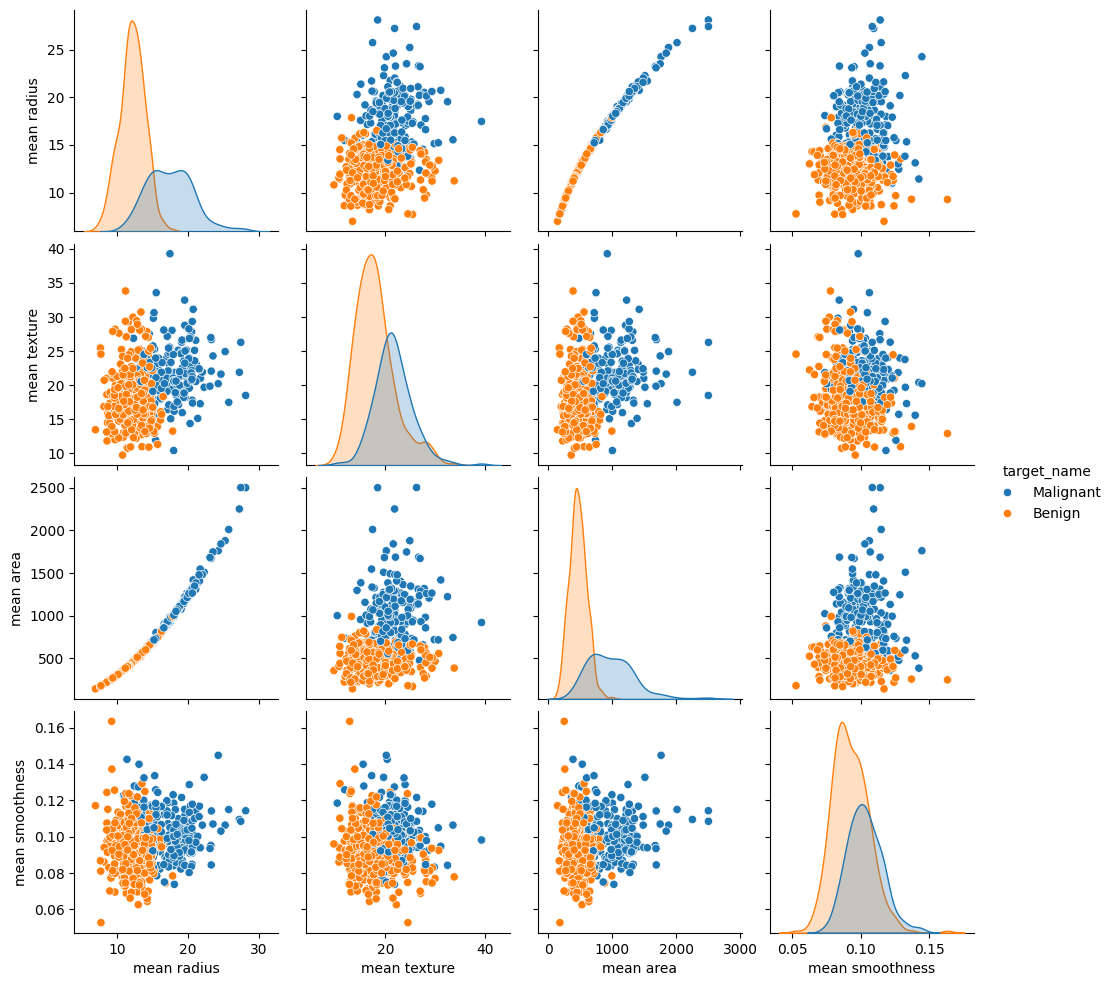

In [40]:
selected = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness",
    "target_name"
]

sns.pairplot(
    df[selected],
    hue="target_name"
)

plt.show()